# 04 — Error Analysis: LightGBM, Random Forest, XGBoost

`03_model_extension.ipynb` found LightGBM the clear leader (PR-AUC 0.245), with Random Forest and
XGBoost tied a step behind (0.229 each). Aggregate metrics can't say *where* each model succeeds
or fails, or whether the two runners-up are making the same mistakes as the leader or genuinely
different ones -- which is exactly what decides whether an ensemble is worth trying later. This
notebook does that: segment-level performance, confusion-matrix error types, cross-model error
overlap, feature-importance comparison, and a qualitative look at specific missed/caught clients.

Per the sequencing agreed with the team, this happens **before** any hyperparameter tuning --
it's cheap (reuses the same out-of-fold predictions as `03`, no new modelling ideas needed to
start), and its findings should decide what gets tuned and whether ensembling is worth trying,
rather than tuning blind.

## Imports and constants

In [142]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from lightgbm import LGBMClassifier
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from xgboost import XGBClassifier

pd.set_option("display.max_columns", 100)

DATA_DIR = Path("data")
PROCESSED_DIR = DATA_DIR / "processed"
TRAINING_FEATURES_PATH = PROCESSED_DIR / "df_training.csv"

RSEED = 42
N_SPLITS = 5
TOP_K_SHARE = 0.10

if not TRAINING_FEATURES_PATH.exists():
    raise FileNotFoundError(
        f"Missing {TRAINING_FEATURES_PATH}. Run 01_eda.ipynb with "
        "SAVE_TRAINING_ARTIFACTS=true first."
    )

## Step 1 — Load the cleaned, client-level features

In [143]:
df = pd.read_csv(TRAINING_FEATURES_PATH)
df["client_id"] = df["client_id"].astype("string")
df["target"] = df["target"].astype("int8")

expected_columns = {
    "client_id", "target",
    "invoice_count", "active_days", "mean_consumption", "zero_consumption_rate",
    "elec_share", "mean_invoice_gap_days", "backwards_index_rate", "meter_count",
    "mean_monthly_submission_index_delta", "backward_submission_rate",
    "large_mismatch_count", "reconciliation_gap_abs_mean",
    "client_catg", "disrict", "region",
}
missing_columns = sorted(expected_columns - set(df.columns))
if missing_columns:
    raise ValueError(f"{TRAINING_FEATURES_PATH} is missing required baseline columns: {missing_columns}")

overview = pd.DataFrame({
    "rows": [len(df)], "unique_clients": [df["client_id"].nunique()], "fraud_rate": [df["target"].mean()],
})
display(overview)

,rows,unique_clients,fraud_rate
0,135493,135493,0.055841


## Step 2 — Preprocessing (identical to `02`/`03`)

This notebook uses the same finalized 15-input contract as the baseline and model extension: 12 numeric features plus the categorical codes `client_catg`, `disrict`, and `region`. Raw dates, tenure, identifiers, and investigation-related fields are not model inputs. Numeric values are median-imputed and scaled; categories are one-hot encoded inside the cross-validation pipeline.

In [144]:
categorical_features = ["client_catg", "region", "disrict"]
numeric_features = [
    "invoice_count", "active_days", "mean_consumption", "zero_consumption_rate",
    "elec_share", "mean_invoice_gap_days", "backwards_index_rate", "meter_count",
    "mean_monthly_submission_index_delta", "backward_submission_rate",
    "large_mismatch_count", "reconciliation_gap_abs_mean",
]

model_features = numeric_features + categorical_features
X = df[model_features]
y = df["target"]
y_values = y.to_numpy()

preprocessor = ColumnTransformer([
    ("numeric", Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
    ]), numeric_features),
    ("categorical", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features),
])

cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RSEED)

## Step 3 — Recompute out-of-fold predictions for the three tree ensembles

Same model configurations as `03_model_extension.ipynb` (same `class_weight`/`scale_pos_weight`,
same seed, same CV) -- duplicated rather than imported so this notebook runs on its own. Only
the three tree ensembles are needed here; logistic regression, KNN, and Isolation Forest already
have their story from `03` and aren't the subject of this analysis.

In [145]:
scale_pos_weight = (y == 0).sum() / (y == 1).sum()

model_specs = {
    "lightgbm": LGBMClassifier(class_weight="balanced", random_state=RSEED, n_jobs=-1, verbosity=-1),
    "random_forest": RandomForestClassifier(class_weight="balanced", random_state=RSEED, n_jobs=-1),
    "xgboost": XGBClassifier(
        scale_pos_weight=scale_pos_weight, eval_metric="logloss", random_state=RSEED, n_jobs=-1
    ),
}

oof_probas = {}
for name, model in model_specs.items():
    pipeline = Pipeline([("preprocess", preprocessor), ("model", model)])
    oof_probas[name] = cross_val_predict(pipeline, X, y, cv=cv, method="predict_proba")[:, 1]
    print(f"done: {name}")

done: lightgbm
done: random_forest
done: xgboost


## Step 4 — Do the three models miss the same fraud, or different fraud?

The question that actually decides whether ensembling is worth trying later: for each fraud
client, count how many of the three models missed them (0 = every model caught them, 3 = every
model missed them). If misses cluster at 0 and 3, the models agree with each other and an
ensemble won't help much. If there's a lot of "missed by exactly 1 or 2," the models are making
different mistakes, and averaging/combining them could genuinely catch more fraud than any one
model alone.

Among all fraud clients, how many of the 3 models missed them:


,fraud_clients
0,2250
1,1066
2,1002
3,3248



Among all non-fraud clients, how many of the 3 models falsely flagged them:


,non_fraud_clients
0,111530
1,6618
2,4377
3,5402


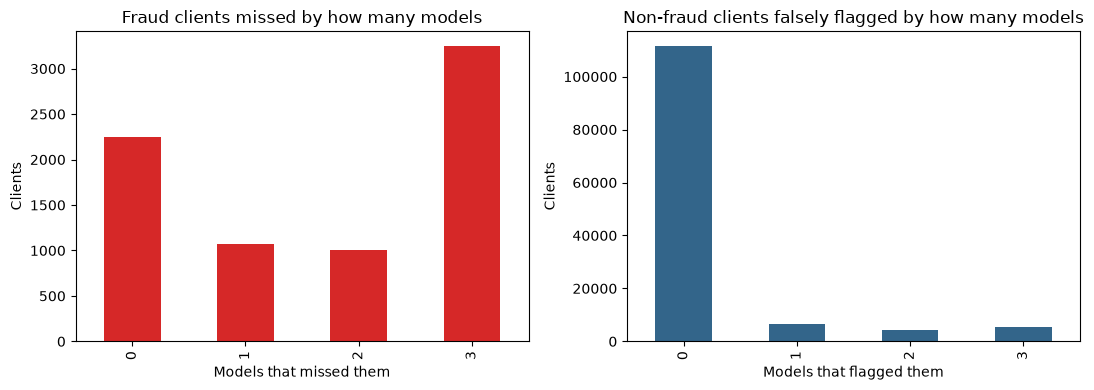

In [146]:
fraud_positions = np.flatnonzero(y_values == 1)
non_fraud_positions = np.flatnonzero(y_values == 0)

missed_by = pd.DataFrame(
    {name: ~flags[name][fraud_positions] for name in model_names}, index=fraud_positions
)
missed_count = missed_by.sum(axis=1)
print("Among all fraud clients, how many of the 3 models missed them:")
display(missed_count.value_counts().sort_index().rename("fraud_clients").to_frame())

falsely_flagged_by = pd.DataFrame(
    {name: flags[name][non_fraud_positions] for name in model_names}, index=non_fraud_positions
)
falsely_flagged_count = falsely_flagged_by.sum(axis=1)
print("\nAmong all non-fraud clients, how many of the 3 models falsely flagged them:")
display(falsely_flagged_count.value_counts().sort_index().rename("non_fraud_clients").to_frame())

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
missed_count.value_counts().sort_index().plot(kind="bar", ax=axes[0], color="#D62828")
axes[0].set(title="Fraud clients missed by how many models", xlabel="Models that missed them", ylabel="Clients")
falsely_flagged_count.value_counts().sort_index().plot(kind="bar", ax=axes[1], color="#33658A")
axes[1].set(title="Non-fraud clients falsely flagged by how many models", xlabel="Models that flagged them", ylabel="Clients")
plt.tight_layout()
plt.show()

## Step 5 — Where the models agree and disagree on catching fraud

Step 4 counted *how many* models missed each fraud client; this section shows *which* clients
and *where*. Two views: a client-by-client scatter of each pair of models' scores (colored by
how many models missed that client), and a segment-level breakdown of the same agreement
categories -- then a dedicated close-up on the clients every model misses, since that's the
group we most need to understand.

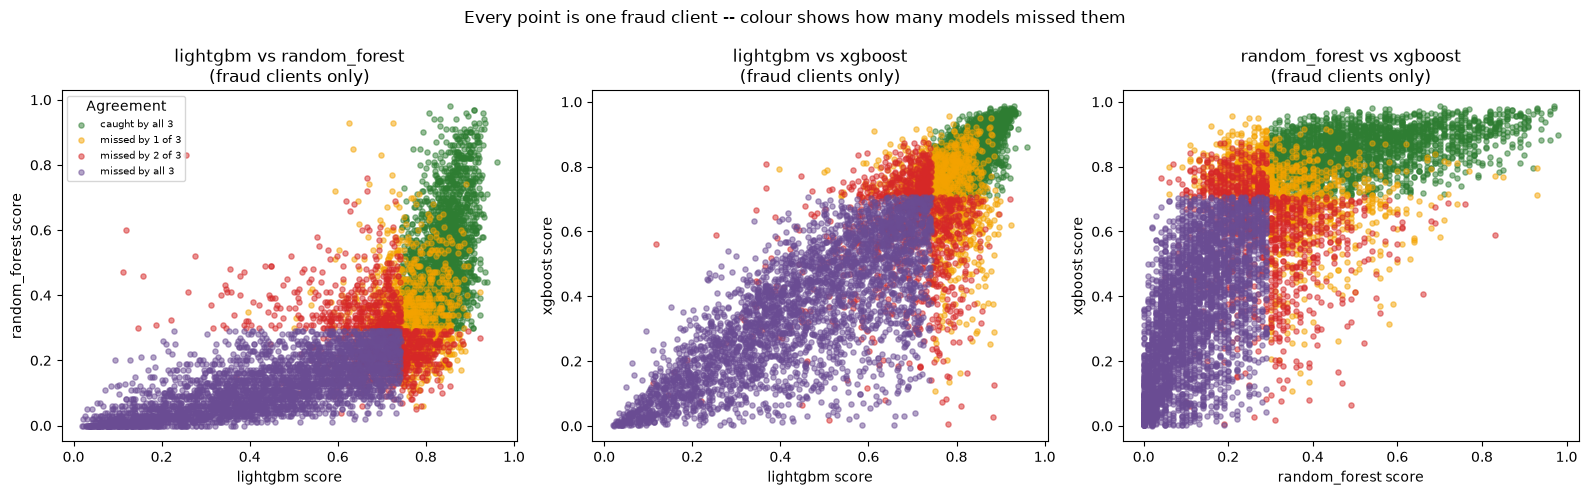

In [147]:
agreement_labels = {
    0: "caught by all 3", 1: "missed by 1 of 3", 2: "missed by 2 of 3", 3: "missed by all 3",
}
fraud_agreement = missed_count.map(agreement_labels)  # index = fraud_positions, from Step 6

palette = {
    "caught by all 3": "#2E7D32", "missed by 1 of 3": "#F4A300",
    "missed by 2 of 3": "#D62828", "missed by all 3": "#6A4C93",
}
agreement_order = list(palette.keys())

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
pairs = [("lightgbm", "random_forest"), ("lightgbm", "xgboost"), ("random_forest", "xgboost")]
for ax, (model_a, model_b) in zip(axes, pairs):
    for label in agreement_order:
        positions = fraud_agreement[fraud_agreement == label].index
        ax.scatter(oof_probas[model_a][positions], oof_probas[model_b][positions],
                   s=14, alpha=0.5, color=palette[label], label=label)
    ax.set(xlabel=f"{model_a} score", ylabel=f"{model_b} score",
           title=f"{model_a} vs {model_b}\n(fraud clients only)")
axes[0].legend(fontsize=7.5, loc="upper left", title="Agreement")
fig.suptitle("Every point is one fraud client -- colour shows how many models missed them")
plt.tight_layout()
plt.show()

### By segment

The same four agreement categories, now broken down by invoice-count quintile and by
`client_catg` -- do the disagreements and unanimous misses concentrate in particular segments,
or are they spread evenly?

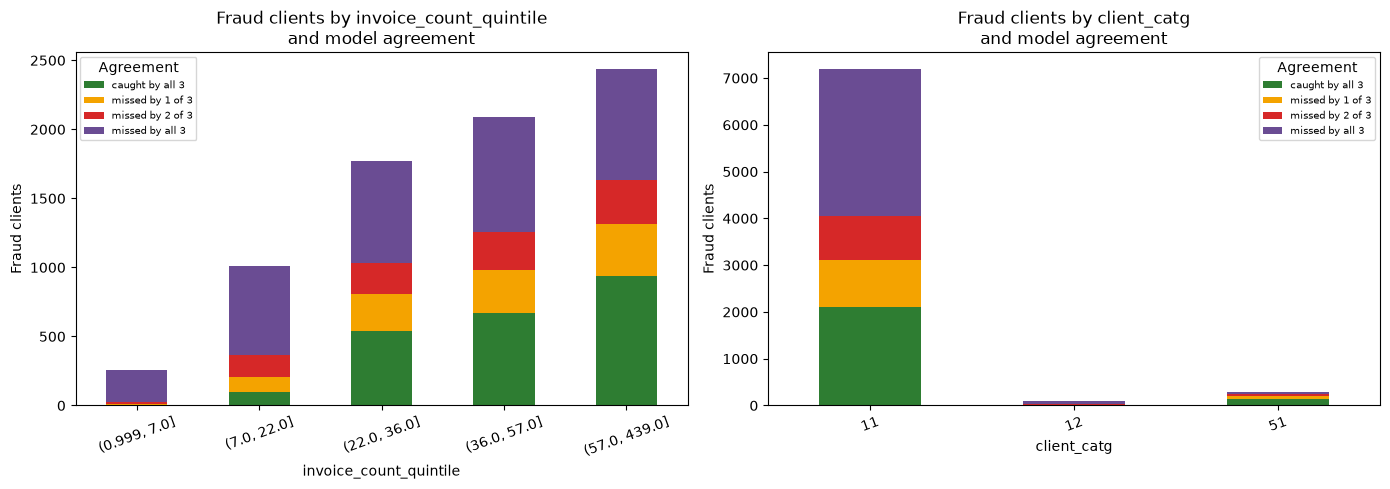

In [148]:
analysis["agreement"] = pd.NA
analysis.loc[fraud_agreement.index, "agreement"] = fraud_agreement.values

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, column in zip(axes, ["invoice_count_quintile", "client_catg"]):
    counts = (
        analysis.dropna(subset=["agreement"])
        .groupby([column, "agreement"], observed=True).size()
        .unstack("agreement").reindex(columns=agreement_order)
    )
    counts.plot(kind="bar", stacked=True, ax=ax, color=[palette[c] for c in agreement_order])
    ax.set(title=f"Fraud clients by {column}\nand model agreement", ylabel="Fraud clients")
    ax.legend(fontsize=7, title="Agreement")
    ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

### A closer look at the fraud clients every model misses

Not mixed in with the other categories this time -- just the "missed by all 3" group on its
own, to see concretely where these clients concentrate.

3248 fraud clients missed by all 3 models -- where do they concentrate?


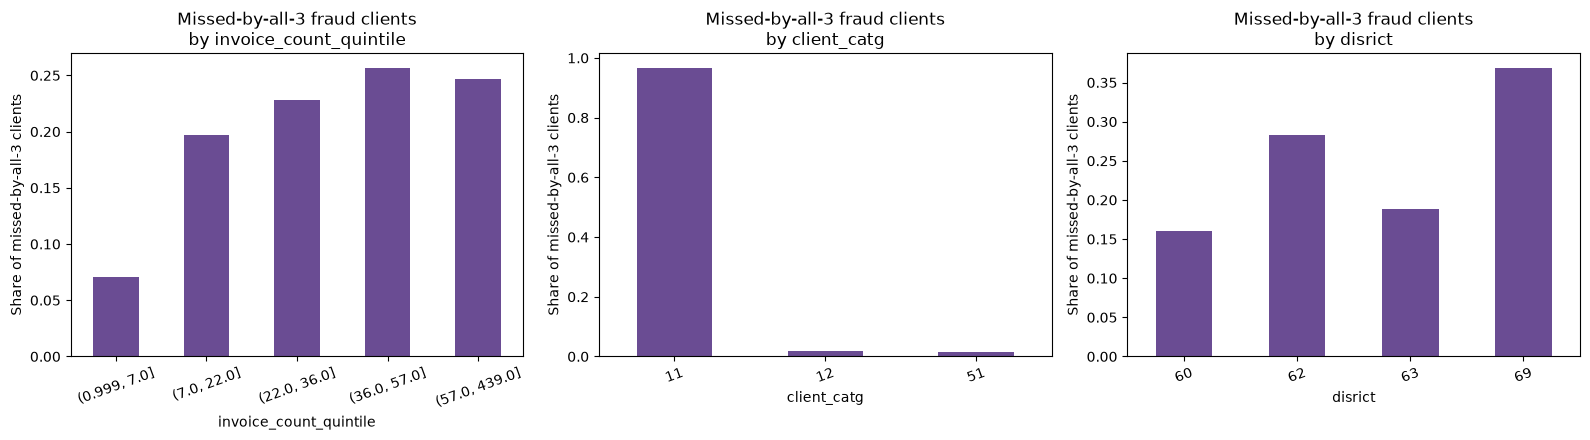

In [149]:
missed_by_all = analysis[analysis["agreement"] == "missed by all 3"]
print(f"{len(missed_by_all)} fraud clients missed by all 3 models -- where do they concentrate?")

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, column in zip(axes, ["invoice_count_quintile", "client_catg", "disrict"]):
    missed_by_all[column].value_counts(normalize=True).sort_index().plot(
        kind="bar", ax=ax, color="#6A4C93"
    )
    ax.set(title=f"Missed-by-all-3 fraud clients\nby {column}", ylabel="Share of missed-by-all-3 clients")
    ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

## Step 6 — Feature importance comparison

Each model uses a different importance metric internally (LightGBM: split count, XGBoost: gain,
Random Forest: impurity decrease) -- these are **not comparable in magnitude across models**,
only within each model's own ranking. Shown side by side to see whether the three models are
relying on similar signals or genuinely different ones.

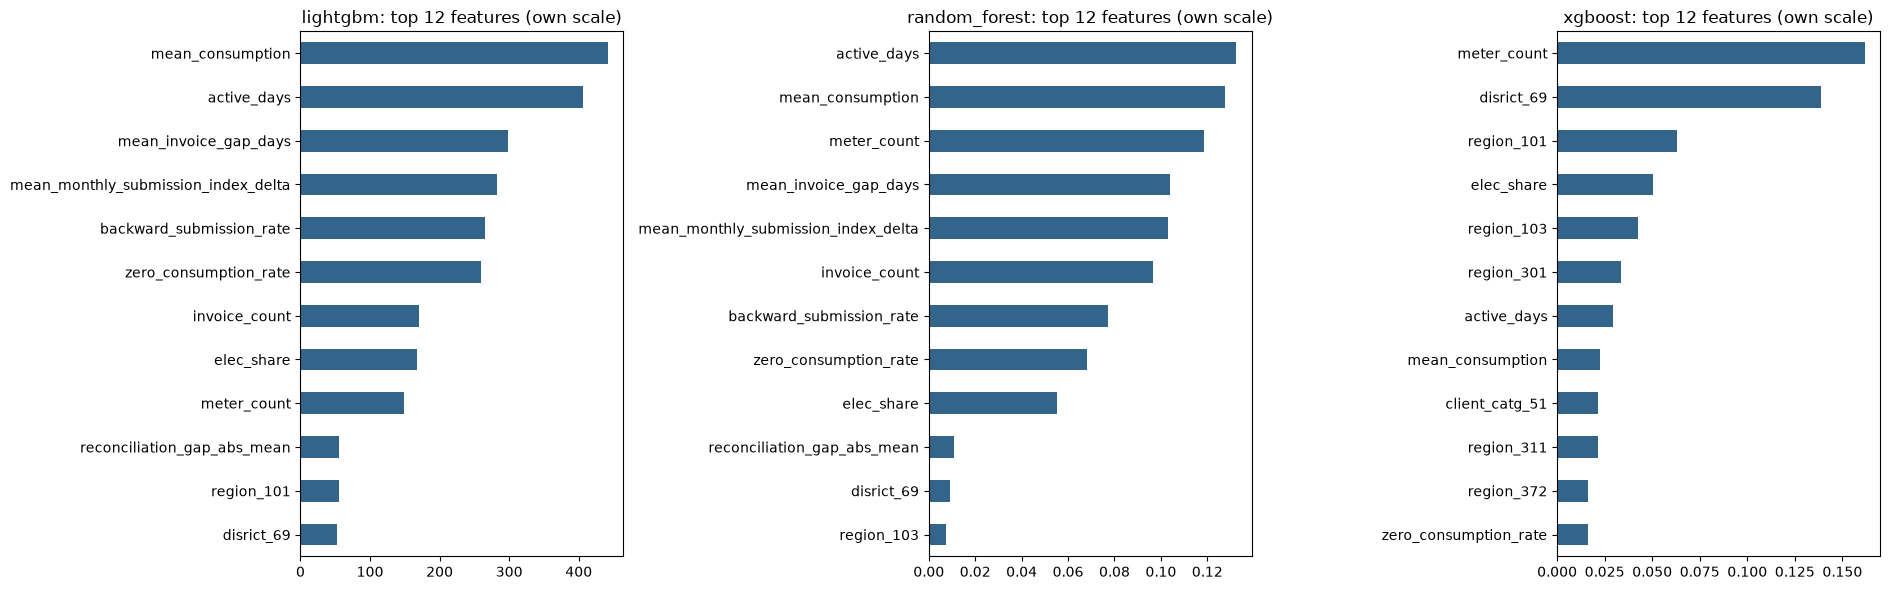

In [150]:
fitted_pipelines = {}
for name, model in model_specs.items():
    pipeline = Pipeline([("preprocess", preprocessor), ("model", model)])
    pipeline.fit(X, y)
    fitted_pipelines[name] = pipeline

feature_names = fitted_pipelines["lightgbm"].named_steps["preprocess"].get_feature_names_out()
feature_names = [name.split("__", 1)[-1] for name in feature_names]

fig, axes = plt.subplots(1, 3, figsize=(19, 6))
for axis, name in zip(axes, model_names):
    importances = fitted_pipelines[name].named_steps["model"].feature_importances_
    top = pd.Series(importances, index=feature_names).sort_values(ascending=False).head(12)
    top.iloc[::-1].plot(kind="barh", ax=axis, color="#33658A")
    axis.set(title=f"{name}: top 12 features (own scale)")
fig.tight_layout()
plt.show()

## Step 7 — A qualitative look at specific clients

A handful of fraud clients every model missed, and a handful every model caught -- not a
statistic, just a sanity-check read on what "hard" and "easy" actually look like here.

In [151]:
inspect_columns = [
    "client_id", "client_catg", "region", "disrict", "invoice_count", "active_days",
    "mean_consumption", "backwards_index_rate", "reconciliation_gap_abs_mean",
]

hardest_positions = missed_count[missed_count == len(model_names)].index
print(f"Fraud clients missed by all {len(model_names)} models: {len(hardest_positions)}")
display(analysis.iloc[hardest_positions][inspect_columns].head(8))

easiest_positions = missed_count[missed_count == 0].index
print(f"\nFraud clients caught by all {len(model_names)} models: {len(easiest_positions)}")
display(analysis.iloc[easiest_positions][inspect_columns].head(8))

Fraud clients missed by all 3 models: 3248


,client_id,client_catg,region,disrict,invoice_count,active_days,mean_consumption,backwards_index_rate,reconciliation_gap_abs_mean
41,train_Client_100032,11,308,63,18,2105,392.555556,0.0,0.000000
97,train_Client_100083,11,107,69,56,4874,314.821429,0.0,3.642857
106,train_Client_100091,11,101,60,43,3065,240.162791,0.0,0.000000
126,train_Client_100109,11,312,63,23,2911,394.956522,0.0,0.000000
152,train_Client_100132,11,106,69,50,4385,1939.600000,0.0,0.000000
249,train_Client_10022,11,107,69,37,4965,548.783784,0.0,0.000000
266,train_Client_100235,11,302,62,9,1004,1292.333333,0.0,0.000000
338,train_Client_10030,11,310,62,14,2187,1371.357143,0.0,0.000000



Fraud clients caught by all 3 models: 2250


,client_id,client_catg,region,disrict,invoice_count,active_days,mean_consumption,backwards_index_rate,reconciliation_gap_abs_mean
201,train_Client_100177,11,306,63,62,5102,264.612903,0.0,0.000000
245,train_Client_100216,11,311,63,52,4854,331.615385,0.0,1.769231
285,train_Client_100252,11,311,63,77,4819,263.909091,0.0,0.000000
312,train_Client_100277,11,104,69,29,5011,670.448276,0.0,0.000000
364,train_Client_100323,11,310,62,83,5101,244.771084,0.0,0.000000
422,train_Client_100376,11,103,69,36,4851,329.250000,0.0,0.000000
539,train_Client_100481,11,311,63,56,4846,359.071429,0.0,0.000000
644,train_Client_100576,11,311,63,118,4880,238.805085,0.0,0.000000


## Step 8 — How much of the 42.4% miss rate is the known short-history story, versus something else?

Step 7 found that 2,563 fraud clients (42.4% of all fraud) are missed by every model. Step 5
already showed the shortest invoice-count quintile collapses to 2.0-3.4% recall -- plausibly a
large share of that 2,563 is just the observation-window blind spot restated. This step separates
the two: which quintile bin(s) are actually collapsed (data-driven, not assumed), what fraction
of the missed-by-all group they explain, and -- for the *rest* of the missed group (long-history
clients still missed by every model) -- how far below each model's own top-10% threshold they
actually score. A client just under the line is a capacity/threshold problem; a client scored low
with confidence is a features problem.

,segment,clients,fraud_cases,lightgbm_recall,random_forest_recall,xgboost_recall,max_recall
0,"(0.999, 7.0]",27354,258,0.023256,0.058140,0.062016,0.062016
1,"(7.0, 22.0]",27857,1008,0.230159,0.218254,0.217262,0.230159
2,"(22.0, 36.0]",26313,1771,0.446076,0.434783,0.463580,0.463580
3,"(36.0, 57.0]",27339,2093,0.465361,0.479216,0.445294,0.479216
4,"(57.0, 439.0]",26630,2436,0.539819,0.545977,0.509442,0.545977


Quintile bin(s) already explained by the known short-history blind spot (max recall across models < 10%): {Interval(0.999, 7.0, closed='right')}

3248 fraud clients missed by all 3 models, split by history bucket:


,clients,share_of_missed_%
history_bucket,,
long history (unexplained),3017,92.9
short history (explained),231,7.1



Among 7,308 long-history fraud clients, 41.3% are still missed by every model -- the residual puzzle once the known short-history blind spot is accounted for.


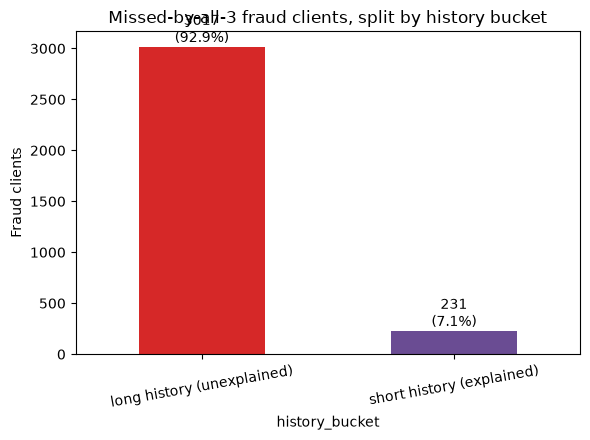

In [152]:
quintile_recall_cols = [f"{name}_recall" for name in model_names]
quintile_by_segment = quintile_table.sort_values("segment").reset_index(drop=True)
quintile_by_segment["max_recall"] = quintile_by_segment[quintile_recall_cols].max(axis=1)
display(quintile_by_segment[["segment", "clients", "fraud_cases"] + quintile_recall_cols + ["max_recall"]])

COLLAPSED_RECALL_THRESHOLD = 0.10  # a quintile bin counts as "already known short-history blind spot"
                                     # if every model's recall there is below this
collapsed_bins = set(
    quintile_by_segment.loc[quintile_by_segment["max_recall"] < COLLAPSED_RECALL_THRESHOLD, "segment"]
)
print(f"Quintile bin(s) already explained by the known short-history blind spot "
      f"(max recall across models < {COLLAPSED_RECALL_THRESHOLD:.0%}): {collapsed_bins}")

analysis["history_bucket"] = np.where(
    analysis["invoice_count_quintile"].isin(collapsed_bins),
    "short history (explained)",
    "long history (unexplained)",
)

missed_by_all = missed_by_all.copy()
missed_by_all["history_bucket"] = analysis.loc[missed_by_all.index, "history_bucket"]

missed_split = missed_by_all["history_bucket"].value_counts()
missed_split_pct = (missed_split / len(missed_by_all) * 100).round(1)
print(f"\n{len(missed_by_all)} fraud clients missed by all 3 models, split by history bucket:")
display(pd.DataFrame({"clients": missed_split, "share_of_missed_%": missed_split_pct}))

long_history_fraud = analysis[(analysis["target"] == 1) & (analysis["history_bucket"] == "long history (unexplained)")]
long_history_missed_rate = (long_history_fraud["agreement"] == "missed by all 3").mean()
print(
    f"\nAmong {len(long_history_fraud):,} long-history fraud clients, "
    f"{long_history_missed_rate:.1%} are still missed by every model -- "
    "the residual puzzle once the known short-history blind spot is accounted for."
)

bucket_colors = {"short history (explained)": "#6A4C93", "long history (unexplained)": "#D62828"}
fig, ax = plt.subplots(figsize=(6, 4.5))
missed_split.plot(kind="bar", ax=ax, color=[bucket_colors[label] for label in missed_split.index])
for i, (label, count) in enumerate(missed_split.items()):
    ax.text(i, count, f"{count}\n({missed_split_pct[label]}%)", ha="center", va="bottom")
ax.set(title="Missed-by-all-3 fraud clients, split by history bucket", ylabel="Fraud clients")
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()

## Step 9 — Is the missed-by-all group hiding in the imputed feature gap?

4,270 train clients have no usable positive-day meter transition, so
`mean_monthly_submission_index_delta` and `backward_submission_rate` are missing for them --
the model pipeline silently median-imputes those clients at fit time. If missed-by-all-3 fraud
clients disproportionately fall in this group, the model isn't just weak on them, it's scoring
them as generically average by construction. The key check is whether this holds up even among
*long-history* clients (an independent blind spot) or is fully explained by short history (the
same story restated).

Clients missing the meter-transition-based features (train set): 5,333
Non-fraud missing rate (baseline): 4.1%



,missing_rate_%
agreement,
caught by all 3,0.0
missed by 1 of 3,0.1
missed by 2 of 3,0.1
missed by all 3,1.6


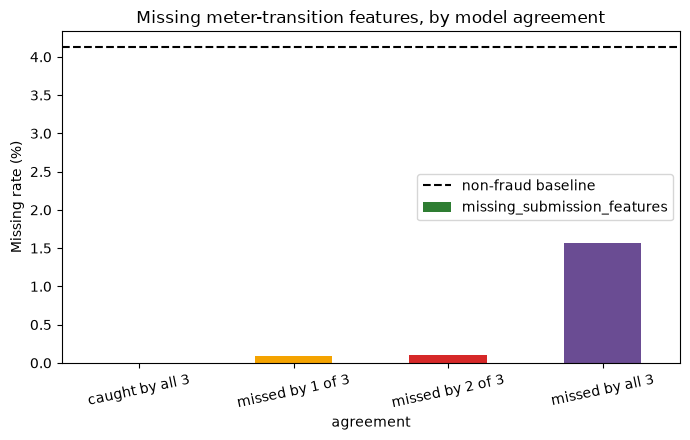


Missing-feature rate by history bucket and model agreement (fraud clients only):


agreement,caught by all 3,missed by 1 of 3,missed by 2 of 3,missed by all 3
history_bucket,,,,
long history (unexplained),0.0,0.0,0.0,0.0
short history (explained),0.0,16.7,5.3,22.1


In [153]:
analysis["missing_submission_features"] = analysis["mean_monthly_submission_index_delta"].isna()
assert (analysis["missing_submission_features"] == analysis["backward_submission_rate"].isna()).all(), \
    "Expected mean_monthly_submission_index_delta and backward_submission_rate to share one missingness mask"

non_fraud_missing_rate = analysis.loc[analysis["target"] == 0, "missing_submission_features"].mean()
missing_by_agreement = (
    analysis.loc[analysis["target"] == 1]
    .groupby("agreement")["missing_submission_features"].mean()
    .reindex(agreement_order)
)

print(f"Clients missing the meter-transition-based features (train set): "
      f"{int(analysis['missing_submission_features'].sum()):,}")
print(f"Non-fraud missing rate (baseline): {non_fraud_missing_rate:.1%}\n")
display((missing_by_agreement * 100).round(1).rename("missing_rate_%").to_frame())

fig, ax = plt.subplots(figsize=(7, 4.5))
(missing_by_agreement * 100).plot(kind="bar", ax=ax, color=[palette[c] for c in agreement_order])
ax.axhline(non_fraud_missing_rate * 100, color="black", linestyle="--", label="non-fraud baseline")
ax.set(title="Missing meter-transition features, by model agreement", ylabel="Missing rate (%)")
ax.legend()
plt.xticks(rotation=12)
plt.tight_layout()
plt.show()

missing_by_history_and_agreement = (
    analysis.loc[analysis["target"] == 1]
    .groupby(["history_bucket", "agreement"])["missing_submission_features"].mean()
    .unstack("agreement").reindex(columns=agreement_order)
)
print("\nMissing-feature rate by history bucket and model agreement (fraud clients only):")
display((missing_by_history_and_agreement * 100).round(1))

## Step 10 — What do the genuinely puzzling clients' actual invoice histories look like?

Steps 8-9 characterize the "missed despite long history" group statistically. This step looks
at a handful of them directly: their real invoice sequences from `data/parquet/invoice_train.parquet`
(raw, per-invoice, never aggregated away) -- a handful of illustrative examples from the group
Steps 8-9 characterize as still puzzling.

> **Leakage note:** `counter_statue` and `reading_remarque` are shown below for these clients'
> records. Both are excluded from every trained model in this project (`01_eda.ipynb` Step 7 --
> their "unusual code" rate jumps sharply at each client's *last* invoice, more so for fraud
> clients, suggesting a later investigation/account-closure event rather than an independent
> predictor). They appear here **only** for human, qualitative inspection of these already-identified
> clients -- no model in this notebook, or anywhere in this project, trains on them.

n≈6 is illustrative, not statistical evidence -- treat this as narrative color for the
presentation, not a finding to act on directly.

In [154]:
puzzling_missed = missed_by_all[missed_by_all["history_bucket"] == "long history (unexplained)"]
print(f"{len(puzzling_missed)} clients missed by all 3 models despite a long invoice history -- "
      "the genuinely puzzling subset examined below.")

N_EXAMPLES = 6
selected_client_ids = puzzling_missed["client_id"].astype("string").head(N_EXAMPLES).tolist()
print(f"\nSelected {len(selected_client_ids)} 'missed despite long history' clients for a qualitative look.")

invoices = pd.read_parquet(DATA_DIR / "parquet" / "invoice_train.parquet")
invoices["client_id"] = invoices["client_id"].astype("string")
client_invoices = invoices[invoices["client_id"].isin(selected_client_ids)].copy()
client_invoices["invoice_date"] = pd.to_datetime(client_invoices["invoice_date"])
client_invoices["index_delta"] = client_invoices["new_index"] - client_invoices["old_index"]
client_invoices = client_invoices.sort_values(["client_id", "invoice_date"])
print(f"Loaded {len(client_invoices):,} raw invoice rows for the {len(selected_client_ids)} selected clients.")

inspect_invoice_columns = [
    "invoice_date", "tarif_type", "counter_type",
    "consommation_level_1", "consommation_level_2", "consommation_level_3", "consommation_level_4",
    "old_index", "new_index", "index_delta", "months_number",
]

for client_id in selected_client_ids:
    client_rows = client_invoices[client_invoices["client_id"] == client_id]
    print(f"\n=== client {client_id} ({len(client_rows)} invoices) ===")
    display(client_rows[inspect_invoice_columns])

    for flag_col in ["counter_statue", "reading_remarque"]:
        modal_code = client_rows[flag_col].mode().iloc[0]
        last_codes = client_rows[flag_col].tail(3)
        anomalous = last_codes[last_codes != modal_code]
        if len(anomalous):
            print(f"  {flag_col}: last 3 codes {last_codes.tolist()} vs. this client's own modal code "
                  f"{modal_code!r} -- {len(anomalous)} of the last 3 differ from their own norm.")
        else:
            print(f"  {flag_col}: last 3 codes match this client's own modal code ({modal_code!r}) -- no anomaly.")

3017 clients missed by all 3 models despite a long invoice history -- the genuinely puzzling subset examined below.

Selected 6 'missed despite long history' clients for a qualitative look.
Loaded 227 raw invoice rows for the 6 selected clients.

=== client train_Client_100032 (18 invoices) ===


,invoice_date,tarif_type,counter_type,consommation_level_1,consommation_level_2,consommation_level_3,consommation_level_4,old_index,new_index,index_delta,months_number
1392,2013-04-03,11,ELEC,303,0,0,0,0,303,303,4
1394,2013-06-25,11,ELEC,293,0,0,0,303,596,293,4
1393,2013-10-30,11,ELEC,403,0,0,0,596,999,403,4
1401,2014-03-03,11,ELEC,259,0,0,0,999,1258,259,4
1391,2014-04-11,11,ELEC,418,0,0,0,1579,1997,418,4
1396,2014-06-27,11,ELEC,321,0,0,0,1258,1579,321,4
1397,2015-02-03,11,ELEC,300,0,0,0,1997,2297,300,4
1398,2015-06-23,11,ELEC,329,0,0,0,2297,2626,329,4
1399,2015-10-28,11,ELEC,450,0,0,0,2626,3076,450,4
1400,2016-02-29,11,ELEC,386,0,0,0,3076,3462,386,4


  counter_statue: last 3 codes match this client's own modal code ('0') -- no anomaly.
  reading_remarque: last 3 codes [9, 9, 6] vs. this client's own modal code np.int16(9) -- 1 of the last 3 differ from their own norm.

=== client train_Client_100083 (56 invoices) ===


,invoice_date,tarif_type,counter_type,consommation_level_1,consommation_level_2,consommation_level_3,consommation_level_4,old_index,new_index,index_delta,months_number
3024,2005-10-11,40,GAZ,0,0,0,0,0,0,0,4
3025,2005-10-11,11,ELEC,758,0,0,0,32944,33702,758,4
3022,2006-03-15,40,GAZ,255,0,0,0,0,255,255,2
3023,2006-03-15,11,ELEC,1,0,0,0,33717,33718,1,2
3000,2006-07-13,40,GAZ,75,0,0,0,255,330,75,4
3021,2006-07-13,11,ELEC,292,0,0,0,33718,34010,292,4
3019,2006-10-11,40,GAZ,50,0,0,0,330,380,50,4
3020,2006-10-11,11,ELEC,488,0,0,0,34010,34498,488,4
3016,2007-03-15,40,GAZ,65,0,0,0,380,445,65,4
3018,2007-03-15,11,ELEC,740,0,0,0,34498,35238,740,4


  counter_statue: last 3 codes match this client's own modal code ('0') -- no anomaly.
  reading_remarque: last 3 codes [9, 9, 6] vs. this client's own modal code np.int16(6) -- 2 of the last 3 differ from their own norm.

=== client train_Client_100091 (43 invoices) ===


...

  counter_statue: last 3 codes match this client's own modal code ('0') -- no anomaly.
  reading_remarque: last 3 codes [9, 9, 9] vs. this client's own modal code np.int16(6) -- 3 of the last 3 differ from their own norm.

=== client train_Client_100132 (50 invoices) ===


,invoice_date,tarif_type,counter_type,consommation_level_1,consommation_level_2,consommation_level_3,consommation_level_4,old_index,new_index,index_delta,months_number
4739,2005-12-20,11,ELEC,1200,891,0,0,17523,19614,2091,4
4767,2005-12-20,40,GAZ,198,0,0,0,28279,28477,198,4
4772,2006-04-27,11,ELEC,1200,2474,0,0,19614,23288,3674,4
4788,2006-04-27,40,GAZ,5491,0,0,0,28477,33968,5491,4
4771,2006-08-23,11,ELEC,1200,699,0,0,23288,25187,1899,4
4773,2006-08-23,40,GAZ,57,0,0,0,33968,34025,57,4
4774,2006-12-20,11,ELEC,1200,851,0,0,25187,27238,2051,4
4780,2006-12-20,40,GAZ,269,0,0,0,34025,34294,269,4
4781,2007-04-26,11,ELEC,1200,1872,0,0,27238,30310,3072,4
4782,2007-04-26,40,GAZ,2777,0,0,0,34294,37071,2777,4


  counter_statue: last 3 codes match this client's own modal code ('0') -- no anomaly.
  reading_remarque: last 3 codes [9, 8, 8] vs. this client's own modal code np.int16(6) -- 3 of the last 3 differ from their own norm.

=== client train_Client_10022 (37 invoices) ===


,invoice_date,tarif_type,counter_type,consommation_level_1,consommation_level_2,consommation_level_3,consommation_level_4,old_index,new_index,index_delta,months_number
7658,2005-11-15,11,ELEC,273,0,0,0,7245,7518,273,4
7663,2006-03-22,11,ELEC,94,0,0,0,7518,7612,94,4
7661,2006-07-18,11,ELEC,858,0,0,0,7612,8470,858,4
7653,2006-11-15,11,ELEC,988,0,0,0,8470,9458,988,4
7660,2007-03-22,11,ELEC,488,0,0,0,9458,9946,488,4
7632,2007-07-19,11,ELEC,1021,0,0,0,9946,10967,1021,4
7659,2007-11-19,11,ELEC,267,0,0,0,10967,11234,267,4
7664,2008-03-26,11,ELEC,590,0,0,0,11234,11824,590,4
7651,2008-07-21,11,ELEC,1010,0,0,0,11824,12834,1010,4
7637,2008-11-19,11,ELEC,899,0,0,0,12834,13733,899,4


  counter_statue: last 3 codes match this client's own modal code ('0') -- no anomaly.
  reading_remarque: last 3 codes match this client's own modal code (np.int16(9)) -- no anomaly.


### Consumption trajectories for the same clients

A visual complement to the tables above -- does a "quiet" fraud client's consumption actually
look flat/stable over time, consistent with the mean/median-divergence hypothesis from Step 10?

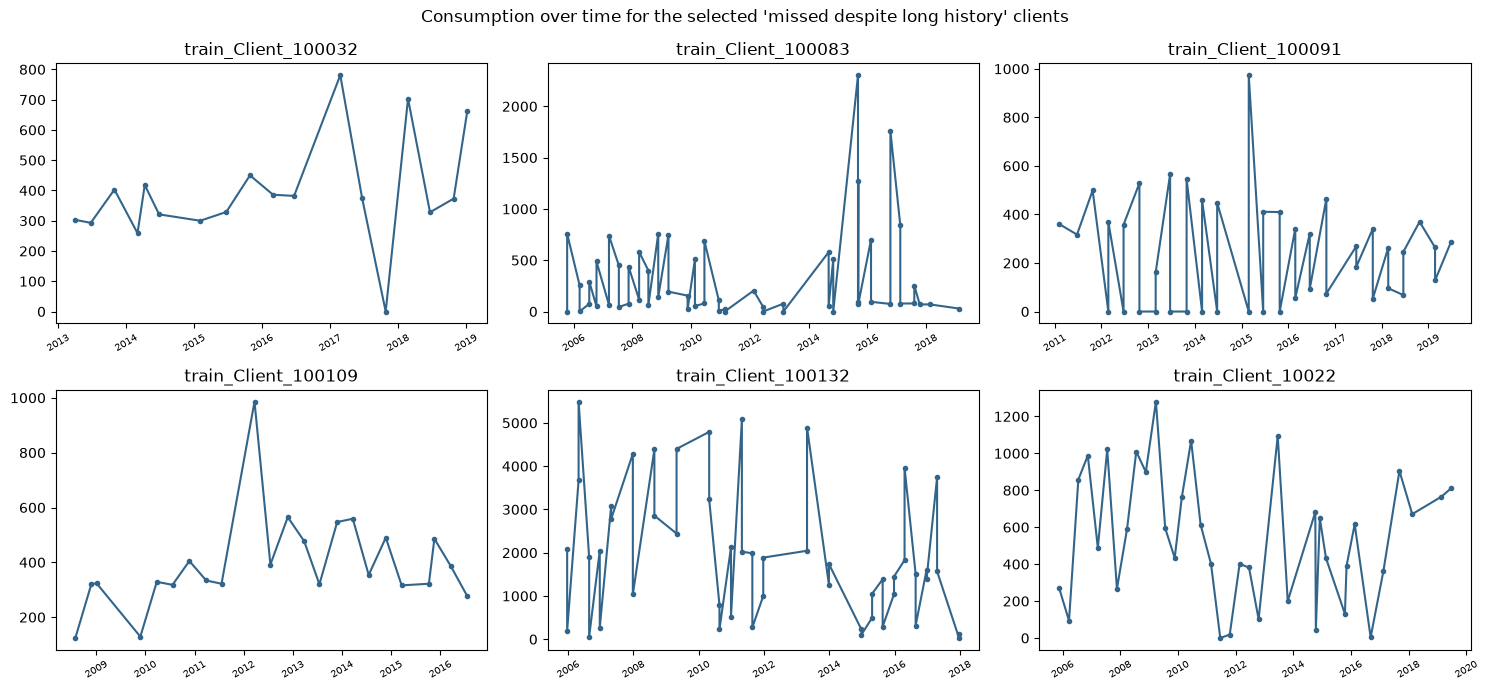

In [155]:
client_invoices["total_consumption"] = client_invoices[
    ["consommation_level_1", "consommation_level_2", "consommation_level_3", "consommation_level_4"]
].sum(axis=1)

n_selected = len(selected_client_ids)
ncols = min(3, n_selected) if n_selected else 1
nrows = int(np.ceil(n_selected / ncols)) if n_selected else 1
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3.5 * nrows), squeeze=False)
for ax, client_id in zip(axes.flat, selected_client_ids):
    client_rows = client_invoices[client_invoices["client_id"] == client_id]
    ax.plot(client_rows["invoice_date"], client_rows["total_consumption"], marker="o", markersize=3, color="#33658A")
    ax.set(title=f"{client_id}")
    ax.tick_params(axis="x", rotation=30, labelsize=7)
for ax in axes.flat[n_selected:]:
    ax.axis("off")
fig.suptitle("Consumption over time for the selected 'missed despite long history' clients")
plt.tight_layout()
plt.show()

### Supporting calculation — current features after controlling for history

The earlier version compared postponed features that are no longer exported in `df_training.csv`. This replacement uses the finalized 15-feature contract only. It compares long-history fraud clients missed by all three models with long-history non-fraud clients, so the result is not simply measuring the known short-history effect.


In [156]:
# Compare the current numeric inputs after restricting both groups to long-history clients.
controlled_numeric_features = [
    column for column in numeric_features
    if column in analysis.columns and column not in {"invoice_count", "active_days"}
]
long_history = analysis[analysis["history_bucket"] == "long history (unexplained)"]
long_history_non_fraud = long_history[long_history["target"] == 0]
long_history_missed = long_history[
    (long_history["target"] == 1)
    & (long_history["agreement"] == "missed by all 3")
]

controlled_rows = []
for feature in controlled_numeric_features:
    reference = long_history_non_fraud[feature].astype(float)
    missed = long_history_missed[feature].astype(float)
    reference_iqr = reference.quantile(0.75) - reference.quantile(0.25)
    if reference_iqr == 0 or pd.isna(reference_iqr):
        effect_size = np.nan
    else:
        effect_size = (missed.median() - reference.median()) / reference_iqr
    controlled_rows.append({
        "feature": feature,
        "long_history_non_fraud_median": reference.median(),
        "long_history_missed_median": missed.median(),
        "effect_size": effect_size,
    })

controlled_result = (
    pd.DataFrame(controlled_rows)
    .set_index("feature")
    .sort_values("effect_size", key=lambda values: values.abs(), ascending=False)
)
print(
    f"Compared {len(long_history_missed):,} long-history missed fraud clients with "
    f"{len(long_history_non_fraud):,} long-history non-fraud clients."
)
display(controlled_result.head(8))


Compared 3,017 long-history missed fraud clients with 100,831 long-history non-fraud clients.


,long_history_non_fraud_median,long_history_missed_median,effect_size
feature,,,
mean_invoice_gap_days,105.900000,92.444444,-0.197042
elec_share,0.690909,0.615385,-0.151049
zero_consumption_rate,0.026316,0.044118,0.145517
mean_consumption,409.469697,451.189655,0.109996
mean_monthly_submission_index_delta,115.748105,128.591611,0.073585
backward_submission_rate,0.107143,0.109375,0.011485
meter_count,2.000000,2.000000,0.000000
backwards_index_rate,0.000000,0.000000,NaN


## Step 11 — Synthesis table

One compact table pulling together Steps 8-9's headline numbers, sized to paste into
`slides.md`'s error-analysis section later (that pasting is out of scope for this notebook --
see the follow-ups note at the end). Cut this step first if time is short; Steps 8-10 already
answer "what makes them different" on their own.

In [157]:
total_fraud_clients = len(fraud_positions)

synthesis_rows = [
    ("Fraud clients missed by all 3 models",
     f"{len(missed_by_all):,} ({len(missed_by_all) / total_fraud_clients:.1%} of all fraud clients)"),
    ("  - short history (explained)",
     f"{missed_split.get('short history (explained)', 0):,} "
     f"({missed_split_pct.get('short history (explained)', 0)}% of the missed group)"),
    ("  - long history (unexplained)",
     f"{missed_split.get('long history (unexplained)', 0):,} "
     f"({missed_split_pct.get('long history (unexplained)', 0)}% of the missed group)"),
    ("Long-history fraud clients still missed by every model",
     f"{long_history_missed_rate:.1%} of {len(long_history_fraud):,} long-history fraud clients"),
    ("Strongest current feature difference after controlling for history",
     f"{controlled_result.index[0]} (effect size {controlled_result['effect_size'].iloc[0]:.2f})"),
    ("Missing meter-transition features: missed-by-all-3 vs. non-fraud baseline",
     f"{missing_by_agreement.get('missed by all 3', float('nan')):.1%} vs. {non_fraud_missing_rate:.1%}"),
]
synthesis_table = pd.DataFrame(synthesis_rows, columns=["Finding", "Value"])

# Plain display() truncates long strings at display.max_colwidth (default 50 chars) and adds a
# noisy numeric index. DataFrame.style needs the optional jinja2 package, which isn't part of
# this project's dependencies -- to_html() is pandas-core-only and avoids that, so it renders
# everywhere this notebook runs without adding a new dependency for one table.
from IPython.display import HTML

with pd.option_context("display.max_colwidth", None):
    synthesis_html = synthesis_table.to_html(index=False, justify="left", escape=False, classes="synthesis-table")

display(HTML(
    "<style>table.synthesis-table td, table.synthesis-table th "
    "{ text-align: left; padding: 6px 14px; }</style>" + synthesis_html
))
print(
    "\nSized to paste into slides.md's error-analysis section -- not done automatically "
    "(see the follow-ups note at the end of this notebook)."
)

Finding,Value
Fraud clients missed by all 3 models,"3,248 (42.9% of all fraud clients)"
- short history (explained),231 (7.1% of the missed group)
- long history (unexplained),"3,017 (92.9% of the missed group)"
Long-history fraud clients still missed by every model,"41.3% of 7,308 long-history fraud clients"
Strongest current feature difference after controlling for history,mean_invoice_gap_days (effect size -0.20)
Missing meter-transition features: missed-by-all-3 vs. non-fraud baseline,1.6% vs. 4.1%



Sized to paste into slides.md's error-analysis section -- not done automatically (see the follow-ups note at the end of this notebook).


## Results

> **Important:** the numerical segment, overlap, and feature-importance notes below were recorded before this notebook was aligned with the finalized 15-input contract. Rerun the cells above before presenting these detailed findings. The aggregate model comparison in `03_model_extension.ipynb` must also be rerun on `df_training.csv` before presenting current numbers.

- **Confusion matrix @ top-10%**: LightGBM leads (precision 24.8%, recall 44.4%), Random Forest
  close behind (23.8% / 42.7%), XGBoost slightly further back (23.6% / 42.3%) -- consistent with
  `03_model_extension.ipynb`'s ranking.
- **`client_catg`**: all three models do noticeably *better* than their overall average on
  category 51 (the ~17%-fraud-rate segment) -- LightGBM 70.0% recall there vs. 44.4% overall --
  and noticeably *worse* on category 12 (recall 10.7-14.7%, but only 75 fraud cases, so read this
  cautiously rather than as a solid finding).
- **`disrict`**: district 63 is easier for every model (recall 55-58%) than the other three
  (35-43%), despite a mid-range fraud rate (6.5%) -- not the obvious "highest-fraud-rate" segment.
- **`region`**: real segment-robustness gap. Region 311 is easy for every model (recall
  62.6-68.0%), while regions 104 and 107 -- both with substantial fraud volume (569 and 524
  cases) -- are hard for every model (recall 24-33%). A strong overall number is hiding a
  meaningfully weaker region.
- **Invoice-count quintile -- the headline finding.** Recall for the shortest-history clients
  (1-7 invoices, 204 fraud cases) collapses to **2.0% (LightGBM), 2.9% (Random Forest), 3.4%
  (XGBoost)** -- essentially none of the fraud in this group is caught, by any model -- compared
  to 45-55% for the longest-history quintile. This is the observation-window bias the EDA flagged
  as a labeling risk, now confirmed as a real, severe *model* blind spot, not just a curiosity
  about the data.
- **Model agreement is high**: of 6,053 fraud clients, 1,746 (28.8%) are caught by all three
  models and 2,563 (42.4%) are missed by all three -- 71% of fraud clients get the *same* verdict
  from every model. Only 1,744 (28.8%) see any disagreement. False positives follow the same
  pattern: 89,089 non-fraud clients are correctly left alone by all three, and only ~13,252 are
  ever flagged by at least one.
- **Feature importance**: LightGBM and Random Forest substantially agree on what matters
  (`active_days`, `meter_count`, consumption and
  invoice-gap features dominate both top-12 lists). **XGBoost is notably different** -- its top
  features are dominated by one-hot geographic codes (`disrict_69`, `region_101`, `region_103`,
  `region_301`, `region_311`), a mechanism the other two barely use at all.

- **Step 7's scatter plots make the agreement finding visually concrete**: fraud clients form
  a clear diagonal band in every pairwise score comparison -- green ("caught by all 3") sits in
  the top-right (all scores high), purple ("missed by all 3") sits in the bottom-left (all
  scores low), and the orange/red disagreement cases fill the off-diagonal band where one model
  scores a client noticeably higher than another.
- **A nuance the segment charts surface that's easy to miss**: the *rate* of being missed is
  worst for short-history clients (the shortest quintile is ~93% purple), but the *absolute
  number* of always-missed fraud clients is actually concentrated more in the longer-history
  quintiles (24.7% of all "missed by all 3" clients come from the longest quintile vs. 7.5% from
  the shortest) -- simply because far more fraud cases exist there in total. Both are true at
  once: short-history clients are proportionally the model's biggest blind spot, but longer-
  history clients still account for more of the raw number of missed fraud cases. Worth stating
  both ways in the presentation rather than picking one.
- `client_catg`'s by-agreement chart is a good visual reminder of the sample-size caveat already
  noted: categories 12 and 51 are so small next to category 11 that their bars are barely
  visible in absolute terms -- read any category-12/51-specific finding as suggestive, not solid.

## Interpretation

- The high agreement between models (71% identical verdicts) explains why LightGBM, Random
  Forest, and XGBoost score similarly in aggregate: they're mostly finding the *same* fraud and
  missing the *same* fraud, not exploring genuinely different parts of the problem. The 2,563
  fraud clients missed by every model are the dataset's genuinely hard cases with the current
  features -- no amount of model-swapping alone is likely to catch them.
- The invoice-count collapse is the single most important finding here. A recall number like
  44% sounds usable for an inspection team, but that average is hiding a near-total blind spot
  for the newest, least-observed clients -- exactly the clients a real fraud program would most
  want early signal on. Reporting one aggregate recall number without this caveat would overstate
  the model's real-world usefulness.
- XGBoost's reliance on `disrict`/`region` one-hot codes is worth flagging as a fairness question,
  not just a technical curiosity: the EDA already cautioned that geographic fraud-rate patterns
  could partly reflect *where inspections have historically happened* rather than true fraud
  propensity (associations, not causes). XGBoost is structurally more exposed to that risk than
  LightGBM/Random Forest, which barely use geography at all -- a real consideration for model
  choice beyond raw PR-AUC.

### Next steps

- **Treat the invoice-count blind spot as the priority**, ahead of hyperparameter tuning: tuning
  a model's settings won't fix a missing-signal problem for short-history clients. Worth trying
  relative/normalized feature versions (e.g., consumption or gap features expressed per-invoice
  or per-active-day rather than as raw sums) that don't structurally require a long history to
  be informative, and stating the limitation explicitly in the presentation regardless.
- **Look closer at regions 104 and 107** before finalizing -- substantial fraud volume, poor
  recall across every model, worth understanding whether that's a genuine harder fraud pattern or
  a data/feature gap specific to those regions. See Step 15 above for a status check.
- **Try a soft (probability-averaging) ensemble of LightGBM + Random Forest** -- they share most
  of their top features and agree most often, so an ensemble is more about smoothing noise than
  combining genuinely different signals; test it against each individual model via the same CV
  scheme before adopting it. An "OR"-style union is not recommended: it would recover some of the
  1,744 disagreement cases but roughly triples the false-positive count (13,252 vs. ~8,000-8,500
  per model alone).
- **Now proceed to hyperparameter tuning of LightGBM** (the confirmed single leader from `03`),
  informed by the above -- and re-check the invoice-count quintile breakdown afterward to confirm
  tuning didn't just improve the easy majority while leaving the short-history blind spot as bad
  as before.
- **`client_catg == 12`'s weak recall** is a low-confidence finding (75 fraud cases) -- flag it,
  don't act on it without more data.